# Predicting food demand at KU Mensa

## Data Collection and Preprocessing

This section describes the process of collecting, cleaning, and merging raw Excel files from the KU Mensa system.

We worked with two different data sources:
- **Produktionsplanung** (production planning): contains planned dishes, target portions, and dish descriptions for each day.
- **Verkaufszahlen** (sales data): contains the actual number of portions sold each day, divided into individually sold items and daily menus labeled as Essen 1, 2, etc.

Important:
- The Excel files had inconsistent formats, missing columns, and irregular positioning of cells.
- Dishes in the sales data were listed as "Essen", requiring cross-referencing with production planning to retrieve full descriptions.



In [1]:
import pandas as pd
import glob
import re

In [2]:
path = 'data/'

### First, extract data from Produktionsplaning Excel files:

In [3]:
prod_files = glob.glob(f"{path}/*Produktionsplanung.xlsx")
prod_dfs = []

In [4]:
for file in prod_files:
    df = pd.read_excel(file)
    
    # leave only the necessary columns (the names are in German and in all files are the same)
    df_reduced = df[['Prod.Dat.', 'Gebinde', 'Bezeichnung', 'Sollmenge', 'Ausgabe']]
    
    # remame for convenience
    df_reduced.columns = ['date', 'gebinde', 'dish_name', 'target_amount', 'output']
    
    # adding it to the dataframelist
    prod_dfs.append(df_reduced)

In [5]:
prod_df = pd.concat(prod_dfs, ignore_index=True)

In [6]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [7]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.1+ KB


Change the format of dates:

In [8]:
prod_df['date'] = pd.to_datetime(prod_df['date'], format='%d/%m/%Y')

In [9]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [10]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.1+ KB


In [11]:
# Sollmenge = 0
print(f"Total rows in all Produktionsplanung: {len(prod_df)}")

total_target_zero = (prod_df['target_amount'] == 0).sum()
print(f"Total rows in prod_df with target_amount=0: {total_target_zero}")

print(f'The proportion of such lines: {total_target_zero / len(prod_df):.2%}')

Total rows in all Produktionsplanung: 16254
Total rows in prod_df with target_amount=0: 2930
The proportion of such lines: 18.03%


### Second, extract data from Verkaufszahlen Excel files:

In [12]:
verkaufs_files = glob.glob('data/*Verkaufszahlen.xlsx')

verkaufs_dfs = []

for file in verkaufs_files:
    df = pd.read_excel(file, header=None)

    #  1. Read dates 

    date_row = df.loc[3, 8:]  

    # Take only non-empty dates
    valid_date_cols = date_row[date_row.notna()]
    
    # Convert to dictionary: {column: date}
    date_map = valid_date_cols.to_dict()

    #  2. Read dish names 

    row_idx = 5 
    while row_idx < len(df):
        dish = df.loc[row_idx, 6] 
        if pd.isna(dish):  
            row_idx += 1
            continue  
        #  3. Read sales for each date 
        for col_idx, raw_date in date_map.items():
            sold = df.loc[row_idx, col_idx]
            if pd.notna(sold):
                verkaufs_dfs.append({
                    'dish_name': dish,
                    'date': pd.to_datetime(raw_date, format='%Y.%m.%d', errors='coerce'),
                    'sold_amount': sold
                })
        row_idx += 1  

verkauf_df = pd.DataFrame(verkaufs_dfs)

# Filter out invalid dates (for example, if there was "Gesamt" somewhere)
verkauf_df = verkauf_df[verkauf_df['date'].notna()]
verkauf_df = verkauf_df.sort_values('date').reset_index(drop=True)

print(verkauf_df.head())


                         dish_name       date  sold_amount
0                   Kartoffelsalat 2014-01-07           74
1                             Reis 2014-01-07           15
2                       Kartoffeln 2014-01-07            3
3  Essen- Soziales ohne Berechnung 2014-01-07            1
4                    Pommes frites 2014-01-07          187


In [13]:
verkauf_df.info()#null-values removed


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   dish_name    13114 non-null  object        
 1   date         13114 non-null  datetime64[ns]
 2   sold_amount  13114 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 307.5+ KB


In [14]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2015-02-12')]#two examples

,dish_name,date,sold_amount
1877,Essen 5,2015-02-12,72
1878,Essen 1,2015-02-12,82
1879,Reis,2015-02-12,5
1880,Kartoffelkloss 200g,2015-02-12,8
1881,Pommes frites,2015-02-12,19
1882,Essen- Soziales ohne Berechnung,2015-02-12,1
1883,Nudeln,2015-02-12,8
1884,Essen 4,2015-02-12,33


In [15]:
prod_df[prod_df['date'] == pd.Timestamp('2015-02-12')]

,date,gebinde,dish_name,target_amount,output
2195,2015-02-12,Reis,Butterreis,15,15
2196,2015-02-12,Kloß 200 gr,"Kloß, 200g",8,8
2197,2015-02-12,Nudeln,Nudeln Spirelli,20,20
2198,2015-02-12,NaN,Kräuterbraten v.Schwein m. Kloß u. Rotk,191,191
2199,2015-02-12,Essen 4 Mensen VK,Kartoffel-Broccoli-Flan,40,40
2200,2015-02-12,Essen 5 Mensen VK,Thai- Wraps mit Chilli-Ingwer-Dip- Vegan,76,76
2201,2015-02-12,Pommes frites,Pommes-Frites,19,19


### Preliminary observations

We have collected data from two different sources:

- `prod_df`: contains information from all *Produktionsplanung* (production planning) Excel files, including planned and actual quantities (`Sollmenge`, `Ausgabe`).
- `verkauf_df`: contains sales data extracted from *Verkaufszahlen* files, representing the actual number of dishes sold per day.

Although the `output` (Ausgabe) column in `prod_df` is meant to reflect the actual number of dishes distributed, it **does not always match** the corresponding sales values found in `verkauf_df`. This discrepancy is likely due to differences in data collection or reporting logic between the two sources.

**Conclusion:**  
For the remainder of the analysis, we will **rely on the data from `verkauf_df`** as the ground truth for the number of dishes sold, since it provides a more accurate and consistent daily breakdown of sales.

Here is a concrete example illustrating the difference between `output` in `prod_df` and `sold_amount` in `verkauf_df` for the date 2020-06-16:

In [16]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2020-06-16')]

,dish_name,date,sold_amount
9542,Essen 4,2020-06-16,55
9543,Pizza veget./vegan,2020-06-16,7
9544,Essen 1,2020-06-16,37
9545,Pizza Fleisch/Fisch,2020-06-16,9


In [17]:
prod_df[prod_df['date'] == pd.Timestamp('2020-06-16')]

,date,gebinde,dish_name,target_amount,output
10785,2020-06-16,Essen 1 Mensen VK,Bratwürste - Fränkische Art,37,37
10786,2020-06-16,Essen 4 Mensen VK,Pasta mit Tomaten-Chilipesto und frische,0,55
10787,2020-06-16,Pizza Fleisch/Fisch,EP - Pizza Speziale,25,9
10788,2020-06-16,Kartoffeln,"Kartoffeln, gar",0,0
10789,2020-06-16,Reis,Reis,5,0
10790,2020-06-16,Pizza vegetarisch/vegan,EP - Pizza Margherita,36,7


In [18]:
# Next, we will clean the 'gebinde' column in prod_df to extract only the relevant part for "Essen" entries.
def extract_essen(gebinde):
    if isinstance(gebinde, str):
        match = re.match(r'(Essen\s\d)', gebinde)
        if match:
            return match.group(1)  # return only "Essen 1"
    return gebinde  # if not Essen — return as is

# Apply to prod_df
prod_df['gebinde_clean'] = prod_df['gebinde'].apply(extract_essen)

In [19]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output,gebinde_clean
0,2014-01-07,Reis,Butterreis,15,15,Reis
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3,Kartoffeln
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80,Kartoffelsalat
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0,Nudeln
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0,Spätzle
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162,Essen 1
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240,Essen 2
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190,Essen 3
8,2014-01-07,Pommes frites,Pommes-Frites,200,200,Pommes frites
9,2014-01-08,Reis,Butterreis,10,10,Reis


### Merging Production Planning and Sales Data

In this section, we combine the production planning (`prod_df`) and sales data (`verkauf_df`) into a single enriched dataset for further analysis and modeling.

In [20]:
# Merge by date and "Essen"
verkauf_df_enriched = verkauf_df.merge(
    prod_df[['date', 'gebinde_clean', 'dish_name', 'target_amount']],
    left_on=['date', 'dish_name'],
    right_on=['date', 'gebinde_clean'],
    how='left'
)

# Create the final column: use the real dish name if found, otherwise keep the original
verkauf_df_enriched['final_dish_name'] = verkauf_df_enriched['dish_name_y'].combine_first(verkauf_df_enriched['dish_name_x'])

# Remove unnecessary columns
verkauf_df_enriched = verkauf_df_enriched[['date', 'dish_name_x', 'target_amount', 'sold_amount', 'final_dish_name']]
verkauf_df_enriched.columns = ['date', 'original_name', 'target_amount', 'sold_amount', 'dish_name']


In [21]:
verkauf_df_enriched.head()

,date,original_name,target_amount,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15.0,15,Butterreis
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,NaN,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites


In [22]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           13132 non-null  datetime64[ns]
 1   original_name  13132 non-null  object        
 2   target_amount  11759 non-null  float64       
 3   sold_amount    13132 non-null  int64         
 4   dish_name      13132 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 513.1+ KB


In some cases, the 'target_amount' (i.e., the planned number of portions) is missing 
because the dish was not listed in the production planning files.


## Visualization

### 1. The most popular dishes
The goal: to find out which dishes were sold most often


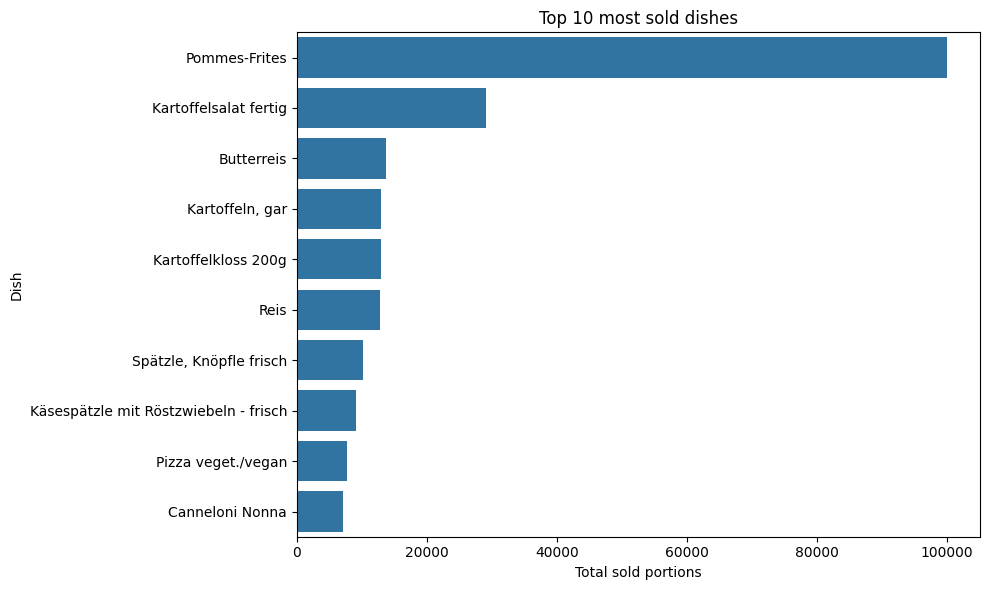

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

top_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_dishes.values, y=top_dishes.index)
plt.title('Top 10 most sold dishes')
plt.xlabel('Total sold portions')
plt.ylabel('Dish')
plt.tight_layout()
plt.show()

### 2. Sales by day of the week
Goal: to understand which days of the week have the most sales

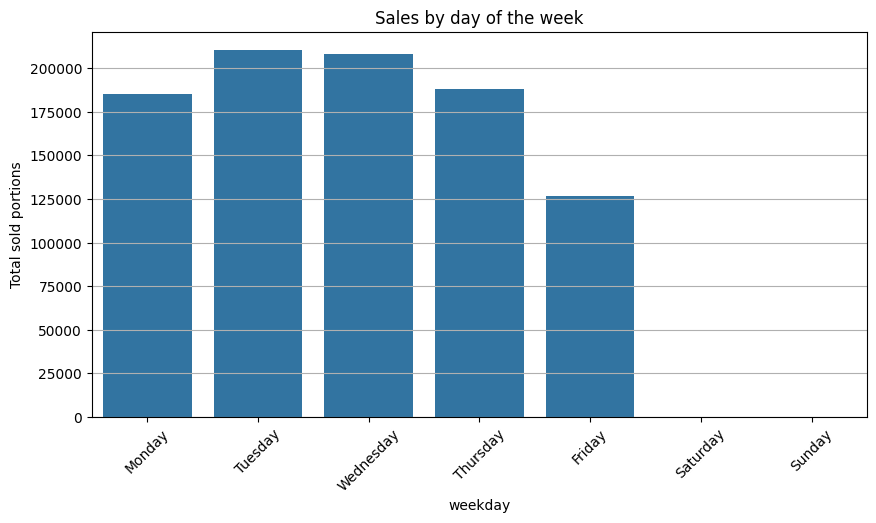

In [24]:
verkauf_df_enriched['weekday'] = pd.to_datetime(verkauf_df_enriched['date']).dt.day_name()

weekday_sales = verkauf_df_enriched.groupby('weekday')['sold_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title('Sales by day of the week')
plt.ylabel('Total sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


### 3. Sales by day of the week (per year)

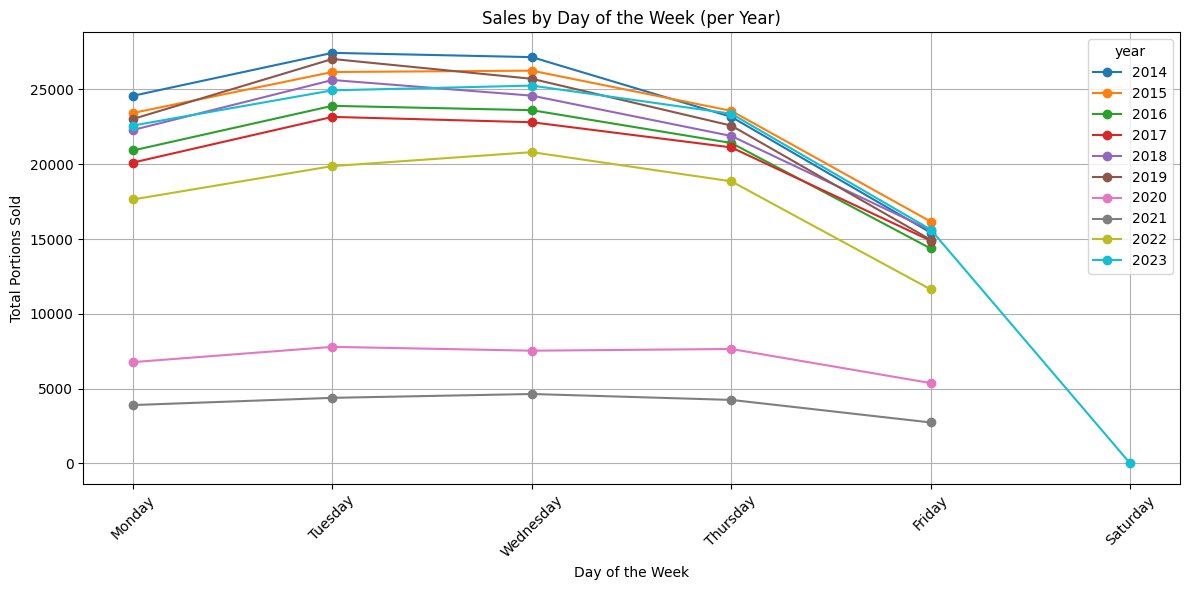

In [25]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

grouped = (
    verkauf_df_enriched
    .groupby(['year', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['year', 'weekday'])

pivot = grouped.pivot(index='weekday', columns='year', values='sold_amount')
pivot = pivot.reindex(weekday_order) 

pivot.plot(kind='line', marker='o', figsize=(12, 6))
plt.title('Sales by Day of the Week (per Year)')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. Comparison of Essen vs. Single Dishes
Goal: Compare total sales of Essen menus and individually sold dishes.
This helps to understand how the demand for different meal types varies by year or day of the week.

In [26]:
def categorize_dish(name):
    if isinstance(name, str) and name.strip().startswith('Essen'):
        return 'Essen (Menu)'
    else:
        return 'Single dish'

verkauf_df_enriched['dish_type'] = verkauf_df_enriched['original_name'].apply(categorize_dish)

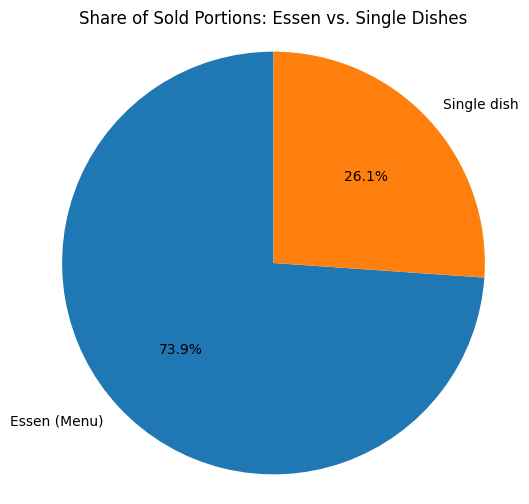

In [27]:

type_summary = verkauf_df_enriched.groupby('dish_type')['sold_amount'].sum()

plt.figure(figsize=(6, 6))
plt.pie(type_summary, labels=type_summary.index, autopct='%1.1f%%', startangle=90)
plt.title('Share of Sold Portions: Essen vs. Single Dishes')
plt.axis('equal') 
plt.show()


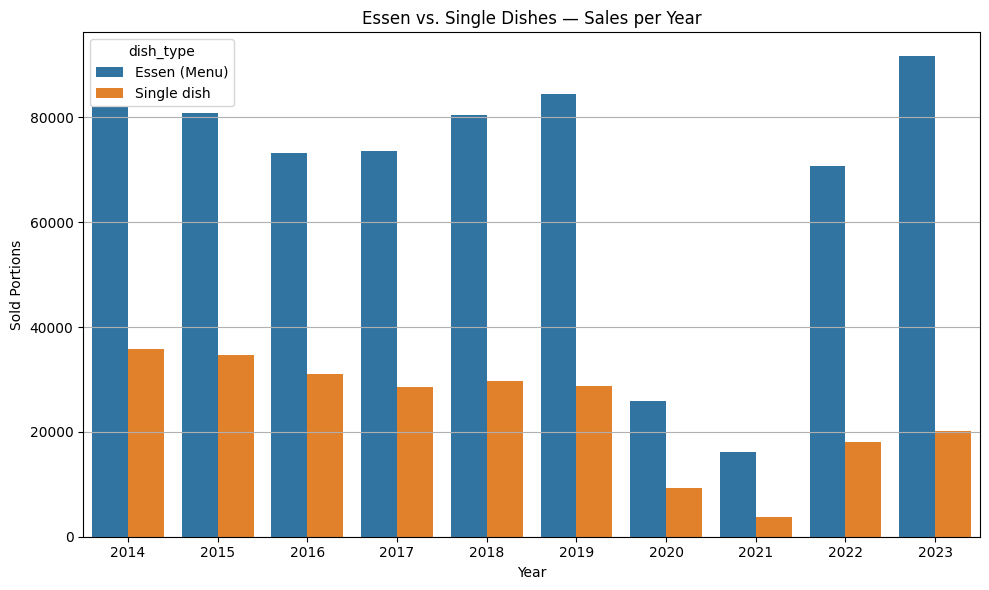

In [28]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
grouped_by_year = verkauf_df_enriched.groupby(['year', 'dish_type'])['sold_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped_by_year, x='year', y='sold_amount', hue='dish_type')
plt.title('Essen vs. Single Dishes — Sales per Year')
plt.ylabel('Sold Portions')
plt.xlabel('Year')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The next analysis is based on 2018 data only.

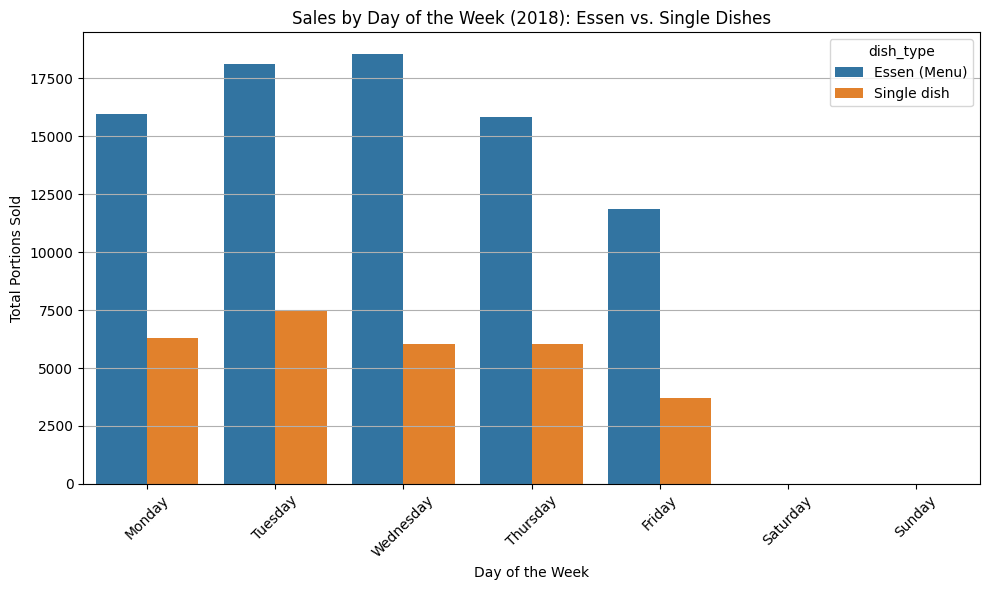

In [29]:
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.day_name()

df_2018 = verkauf_df_enriched[verkauf_df_enriched['year'] == 2018]

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
grouped = (
    df_2018
    .groupby(['dish_type', 'weekday'])['sold_amount']
    .sum()
    .reset_index()
)
grouped['weekday'] = pd.Categorical(grouped['weekday'], categories=weekday_order, ordered=True)
grouped = grouped.sort_values(['weekday', 'dish_type'])

plt.figure(figsize=(10, 6))
sns.barplot(data=grouped, x='weekday', y='sold_amount', hue='dish_type')
plt.title('Sales by Day of the Week (2018): Essen vs. Single Dishes')
plt.xlabel('Day of the Week')
plt.ylabel('Total Portions Sold')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

### 5. Some more visualisations
Goal: to get a better understanding of data (is it "seasoned", what about sales in COVID-Period, lecture-free periods etc.)

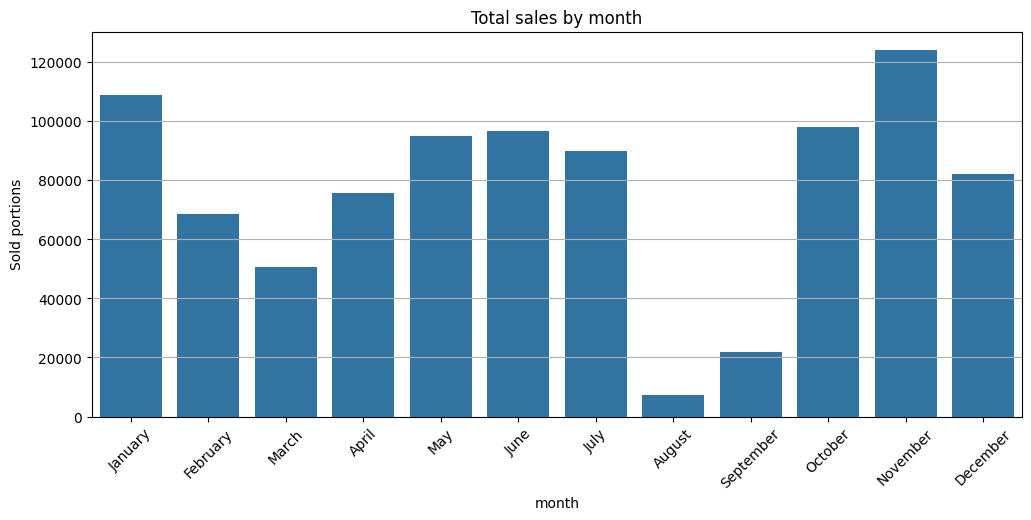

In [30]:
verkauf_df_enriched['month'] = pd.to_datetime(verkauf_df_enriched['date']).dt.month_name()

monthly_sales = verkauf_df_enriched.groupby('month')['sold_amount'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title('Total sales by month')
plt.ylabel('Sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

How popular is a dish overall

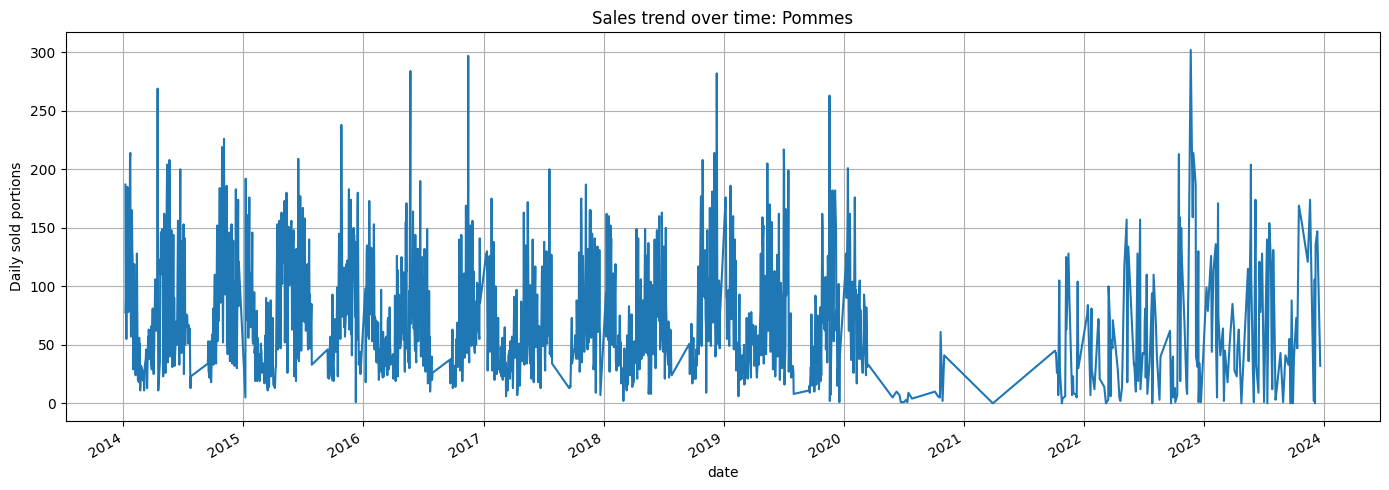

In [31]:
dish_name = 'Pommes'
df = verkauf_df_enriched[verkauf_df_enriched['dish_name'].str.contains(dish_name, case=False, na=False)]

daily_sales = df.groupby('date')['sold_amount'].sum()

plt.figure(figsize=(14, 5))
daily_sales.plot()
plt.title(f'Sales trend over time: {dish_name}')
plt.ylabel('Daily sold portions')
plt.grid()
plt.tight_layout()
plt.show()

Top 5 popular dishes plotted

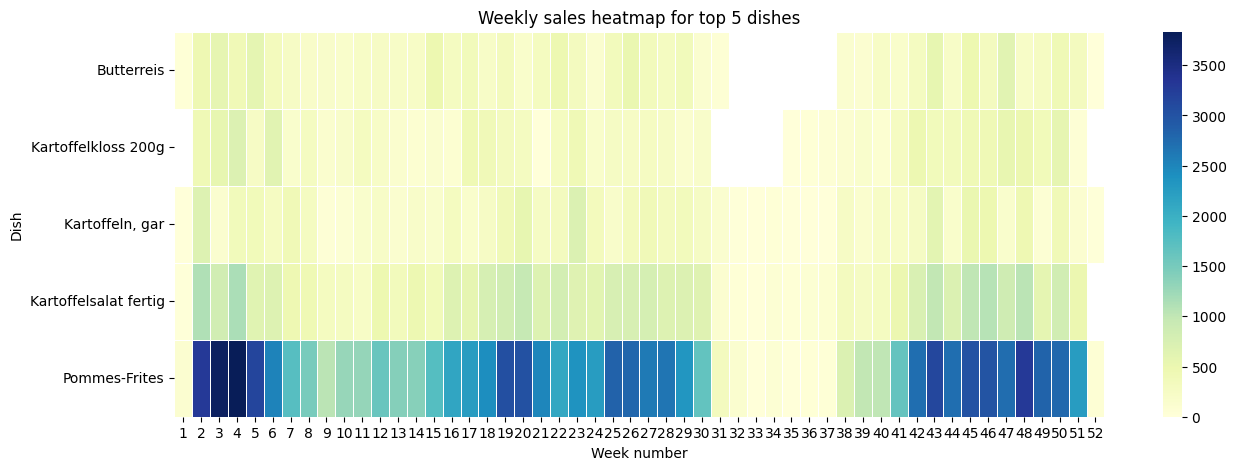

In [32]:
verkauf_df_enriched['weekofyear'] = verkauf_df_enriched['date'].dt.isocalendar().week

# Top 5 popular dishes plotted
top5_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(5).index

heatmap_data = verkauf_df_enriched[verkauf_df_enriched['dish_name'].isin(top5_dishes)]
heatmap_pivot = heatmap_data.pivot_table(index='dish_name', columns='weekofyear', values='sold_amount', aggfunc='sum')

plt.figure(figsize=(15, 5))
sns.heatmap(heatmap_pivot, cmap='YlGnBu', linewidths=0.5)
plt.title('Weekly sales heatmap for top 5 dishes')
plt.xlabel('Week number')
plt.ylabel('Dish')
plt.show()

## Feature Engineering

### Time features

In [33]:
verkauf_df_enriched['date'] = pd.to_datetime(verkauf_df_enriched['date'])

#Time features
verkauf_df_enriched['year'] = verkauf_df_enriched['date'].dt.year
verkauf_df_enriched['month'] = verkauf_df_enriched['date'].dt.month#1–12
verkauf_df_enriched['day'] = verkauf_df_enriched['date'].dt.day#1–31
verkauf_df_enriched['weekday'] = verkauf_df_enriched['date'].dt.weekday  # 0 = monday
verkauf_df_enriched['weekofyear'] = verkauf_df_enriched['date'].dt.isocalendar().week#week in year number
verkauf_df_enriched[['date', 'year', 'month', 'day', 'weekday', 'weekofyear']].head()

,date,year,month,day,weekday,weekofyear
0,2014-01-07,2014,1,7,1,2
1,2014-01-07,2014,1,7,1,2
2,2014-01-07,2014,1,7,1,2
3,2014-01-07,2014,1,7,1,2
4,2014-01-07,2014,1,7,1,2


### Rolling Features

To capture temporal trends and short-term seasonality in dish sales, we created **rolling average** and **rolling median** features.

For each dish, we computed:

- **7-day rolling mean and median** of `sold_amount`
- **30-day rolling mean and median** of `sold_amount`

These features summarize the recent sales and planning history (excluding the current day via `.shift(1)`), allowing the model to learn from past behavior.

This approach helps improve predictions, especially for frequently repeated dishes.


- Week (short trend)

In [34]:


# sold_amount- mean for 7 days, if no histiry/mew dish-NaN
verkauf_df_enriched['rolling_7d_sold_mean'] = (
    verkauf_df_enriched.groupby('original_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# 7 day median sales
verkauf_df_enriched['rolling_7d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).median())
)

verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_7d_sold_mean','rolling_7d_sold_median']].tail(10)

,date,original_name,sold_amount,rolling_7d_sold_mean,rolling_7d_sold_median
13122,2023-12-20,Essen 5,106,200.142857,267.0
13123,2023-12-20,Reis,2,4.857143,4.0
13124,2023-12-20,Essen 1,69,151.857143,108.0
13125,2023-12-20,Essen 4,325,202.000000,324.0
13126,2023-12-21,Essen freier Preis,8,8.000000,5.0
13127,2023-12-21,Essen 4,167,214.714286,132.0
13128,2023-12-21,Pommes frites,32,97.714286,121.0
13129,2023-12-21,Kartoffelsalat,4,37.142857,22.0
13130,2023-12-21,Essen 1,115,140.000000,86.0
13131,2023-12-22,Essen freier Preis,13,8.285714,5.0


It is better to replace dish_name and original_name with one single normalized feature when the LLM is ready.

- Month (long trend)

In [35]:
# 30 days mean  (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_mean'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
)


# 30 days median (no info-Nan)
verkauf_df_enriched['rolling_30d_sold_median'] = (
    verkauf_df_enriched.groupby('dish_name')['sold_amount']
    .transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).median())
)

verkauf_df_enriched[['date', 'original_name', 'sold_amount', 'rolling_30d_sold_mean','rolling_30d_sold_median']].tail(10)

,date,original_name,sold_amount,rolling_30d_sold_mean,rolling_30d_sold_median
13122,2023-12-20,Essen 5,106,267.000000,267.0
13123,2023-12-20,Reis,2,9.400000,3.0
13124,2023-12-20,Essen 1,69,90.687500,93.5
13125,2023-12-20,Essen 4,325,235.333333,210.5
13126,2023-12-21,Essen freier Preis,8,6.666667,4.0
13127,2023-12-21,Essen 4,167,132.000000,132.0
13128,2023-12-21,Pommes frites,32,61.600000,43.0
13129,2023-12-21,Kartoffelsalat,4,32.866667,21.5
13130,2023-12-21,Essen 1,115,116.545455,86.0
13131,2023-12-22,Essen freier Preis,13,6.900000,4.5


In [36]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     13132 non-null  datetime64[ns]
 1   original_name            13132 non-null  object        
 2   target_amount            11759 non-null  float64       
 3   sold_amount              13132 non-null  int64         
 4   dish_name                13132 non-null  object        
 5   weekday                  13132 non-null  int32         
 6   year                     13132 non-null  int32         
 7   dish_type                13132 non-null  object        
 8   month                    13132 non-null  int32         
 9   weekofyear               13132 non-null  UInt32        
 10  day                      13132 non-null  int32         
 11  rolling_7d_sold_mean     13095 non-null  float64       
 12  rolling_7d_sold_median   12001 n

- Rolling Statistics for Total Daily Sales

For each dish, we computed:

- **7-day rolling** of `daily_total_sales`
- **30-day rolling** of `daily_total_sales`

In [37]:
#adding daily total sales column
daily_sales = verkauf_df_enriched.groupby('date')['sold_amount'].sum().rename('daily_total_sales')

verkauf_df_enriched = verkauf_df_enriched.merge(daily_sales, on='date')

verkauf_df_enriched['rolling_7d_total_sales'] = (
    verkauf_df_enriched['daily_total_sales'].shift(1).rolling(window=7, min_periods=1).mean()
)

verkauf_df_enriched[['date', 'sold_amount', 'daily_total_sales', 'rolling_7d_total_sales']].tail(10)


,date,sold_amount,daily_total_sales,rolling_7d_total_sales
13122,2023-12-20,106,505,530.428571
13123,2023-12-20,2,505,531.428571
13124,2023-12-20,69,505,526.142857
13125,2023-12-20,325,505,520.857143
13126,2023-12-21,8,326,515.571429
13127,2023-12-21,167,326,484.714286
13128,2023-12-21,32,326,453.857143
13129,2023-12-21,4,326,428.285714
13130,2023-12-21,115,326,402.714286
13131,2023-12-22,13,13,377.142857


In [38]:
verkauf_df_enriched['rolling_30d_total_sales'] = (
    verkauf_df_enriched['daily_total_sales'].shift(1).rolling(window=30, min_periods=1).mean()
)

verkauf_df_enriched[['date', 'sold_amount', 'daily_total_sales', 'rolling_7d_total_sales', 'rolling_30d_total_sales']].tail(10)


,date,sold_amount,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales
13122,2023-12-20,106,505,530.428571,604.333333
13123,2023-12-20,2,505,531.428571,590.833333
13124,2023-12-20,69,505,526.142857,577.333333
13125,2023-12-20,325,505,520.857143,573.533333
13126,2023-12-21,8,326,515.571429,569.733333
13127,2023-12-21,167,326,484.714286,559.966667
13128,2023-12-21,32,326,453.857143,550.200000
13129,2023-12-21,4,326,428.285714,534.300000
13130,2023-12-21,115,326,402.714286,518.400000
13131,2023-12-22,13,13,377.142857,502.500000


In [39]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     13132 non-null  datetime64[ns]
 1   original_name            13132 non-null  object        
 2   target_amount            11759 non-null  float64       
 3   sold_amount              13132 non-null  int64         
 4   dish_name                13132 non-null  object        
 5   weekday                  13132 non-null  int32         
 6   year                     13132 non-null  int32         
 7   dish_type                13132 non-null  object        
 8   month                    13132 non-null  int32         
 9   weekofyear               13132 non-null  UInt32        
 10  day                      13132 non-null  int32         
 11  rolling_7d_sold_mean     13095 non-null  float64       
 12  rolling_7d_sold_median   12001 n

### Handling Missing Values in Rolling Features

The rolling statistics (mean/median over 7 and 30 days) contain missing values at the beginning of each dish's sales history, because there is not enough past data for the rolling window.

To avoid losing useful rows during modeling, we fill these missing values with the mean of each corresponding column. This provides a reasonable estimate and allows the model to still benefit from the rolling features, especially when history is short.


In [40]:
rolling_cols = [col for col in verkauf_df_enriched.columns if 'rolling_' in col]
verkauf_df_enriched[rolling_cols] = verkauf_df_enriched[rolling_cols].fillna(verkauf_df_enriched[rolling_cols].mean())


In [41]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     13132 non-null  datetime64[ns]
 1   original_name            13132 non-null  object        
 2   target_amount            11759 non-null  float64       
 3   sold_amount              13132 non-null  int64         
 4   dish_name                13132 non-null  object        
 5   weekday                  13132 non-null  int32         
 6   year                     13132 non-null  int32         
 7   dish_type                13132 non-null  object        
 8   month                    13132 non-null  int32         
 9   weekofyear               13132 non-null  UInt32        
 10  day                      13132 non-null  int32         
 11  rolling_7d_sold_mean     13132 non-null  float64       
 12  rolling_7d_sold_median   13132 n

### Dish frequency:

In [42]:
dish_freq = verkauf_df_enriched['original_name'].value_counts()
verkauf_df_enriched['dish_freq'] = verkauf_df_enriched['original_name'].map(dish_freq)


### Single dishes

In [43]:
df_single_dishes = verkauf_df_enriched[verkauf_df_enriched['dish_type'] == 'Single dish'].copy()

In [44]:
unique_original_names = df_single_dishes['original_name'].value_counts()
print(f"Total unique original_names: {unique_original_names.shape[0]}")

Total unique original_names: 25


In [45]:
unique_original_names

original_name
Reis                                     1506
Pommes frites                            1417
Kartoffelsalat                            945
Kartoffeln                                625
Nudeln                                    511
Spätzle                                   351
Pizza veget./vegan                        317
Pizza Fleisch/Fisch                       305
Kartoffelkloss 200g                       209
Kartoffelpüree                            196
Röstkartoffeln                            140
Aufschlag Beilagenwechsel                 122
Pommes Wedges                             106
Kroketten                                  65
Semmelkloss                                30
Aufschlag Wechsel frittierte Beilagen      24
Beilage Fleisch/Wurst                      18
Süßkartoffel Pommes                        14
Tomatenreis                                 6
Gemüsereis                                  4
Beilage Kartoffeln                          3
Schöpfgericht 1,80€ 

### Essen or Single:

In [46]:
verkauf_df_enriched['is_essen'] = (verkauf_df_enriched['dish_type'] == 'Essen (Menu)').astype(int)


In [47]:
verkauf_df_enriched.head(10)

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,day,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,510.153182,510.445974,945,0
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1506,0
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,625,0
3,2014-01-07,Essen- Soziales ohne Berechnung,NaN,1,Essen- Soziales ohne Berechnung,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,192,1
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1417,0
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,419,1
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1304,1
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1812,1
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH),2,2014,Single dish,1,2,8,70.102019,63.182901,66.668705,62.374719,676,861.000000,861.000000,140,0
9,2014-01-08,Nudeln,1.0,1,Nudeln Fusilli,2,2014,Single dish,1,2,8,70.102019,63.182901,66.668705,62.374719,676,834.571429,840.444444,511,0


In [48]:
verkauf_df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13132 entries, 0 to 13131
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   date                     13132 non-null  datetime64[ns]
 1   original_name            13132 non-null  object        
 2   target_amount            11759 non-null  float64       
 3   sold_amount              13132 non-null  int64         
 4   dish_name                13132 non-null  object        
 5   weekday                  13132 non-null  int32         
 6   year                     13132 non-null  int32         
 7   dish_type                13132 non-null  object        
 8   month                    13132 non-null  int32         
 9   weekofyear               13132 non-null  UInt32        
 10  day                      13132 non-null  int32         
 11  rolling_7d_sold_mean     13132 non-null  float64       
 12  rolling_7d_sold_median   13132 n

## Models

### 1. Model on the Full Data Frame

In this section, we train models on the entire `verkauf_df_enriched` dataset to evaluate baseline performance before dish names are fully standardized. This provides an initial benchmark for prediction accuracy using the available features, even though dish names may still be inconsistent or ungrouped.


**Target Variable**

Our goal is to predict the number of sold portions for each dish on a given day. Thus, we define **`sold_amount`** as the target variable for our regression task.

This target is continuous and numerical, making this a classic **regression problem**.


In [49]:
y = verkauf_df_enriched['sold_amount']

features = [
    'year', 'month', 'day', 'weekday', 'weekofyear',
    'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales',
    'dish_freq', 'is_essen'
]
X = verkauf_df_enriched[features]

**Train/Test Split Strategy**

Since we are working with time series data, it is crucial to avoid data leakage by using a chronological split.

We sorted the dataset by date and used the **first 80%** of the observations as the training set, and the **remaining 20%** as the test set.  
This ensures that the model only sees past data when making predictions on the future, simulating a real-world forecasting scenario.


In [50]:
verkauf_df_enriched = verkauf_df_enriched.sort_values('date')

split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]


**Random Forest**

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF_full = mean_absolute_error(y_test, y_pred)
R2_RF_full = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))


Random Forest evaluation:
MAE: 27.756962314427106
R²: 0.7144022717281893


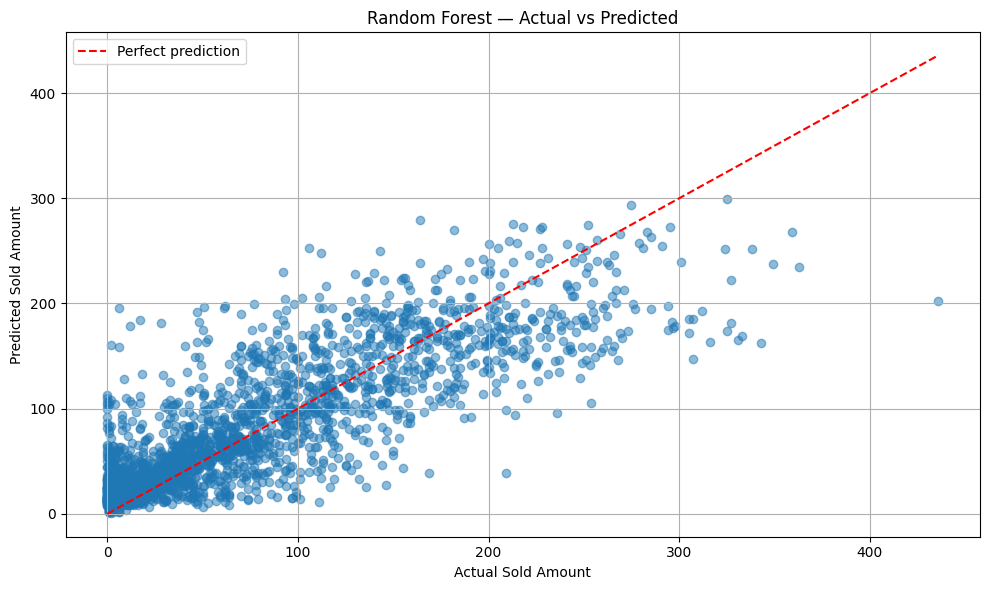

In [52]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Random Forest — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

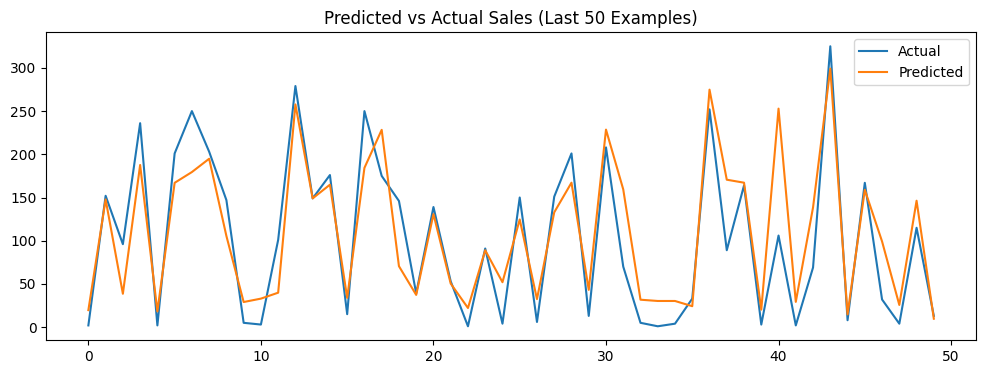

In [53]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[-50:], label='Actual')
plt.plot(y_pred[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

**Linear Regression**

In [54]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

MAE_LR_full = mean_absolute_error(y_test, y_pred_lr)
R2_LR_full = r2_score(y_test, y_pred_lr)

print("Linear Regression evaluation:")
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Linear Regression R²:", r2_score(y_test, y_pred_lr))


Linear Regression evaluation:
Linear Regression MAE: 30.227219973640235
Linear Regression R²: 0.6845980097683959


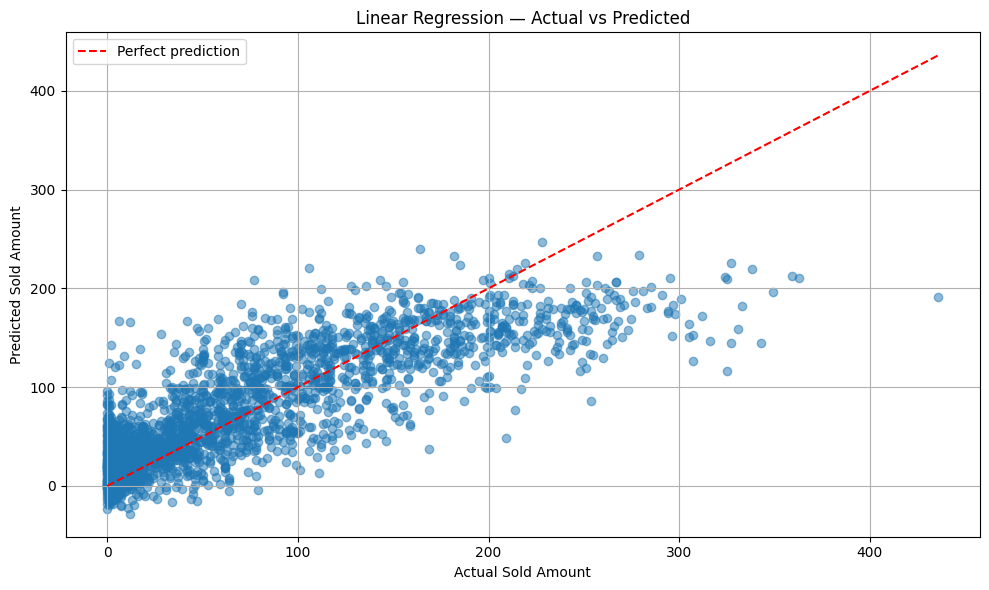

In [55]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', label='Perfect prediction')

plt.xlabel('Actual Sold Amount')
plt.ylabel('Predicted Sold Amount')
plt.title('Linear Regression — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

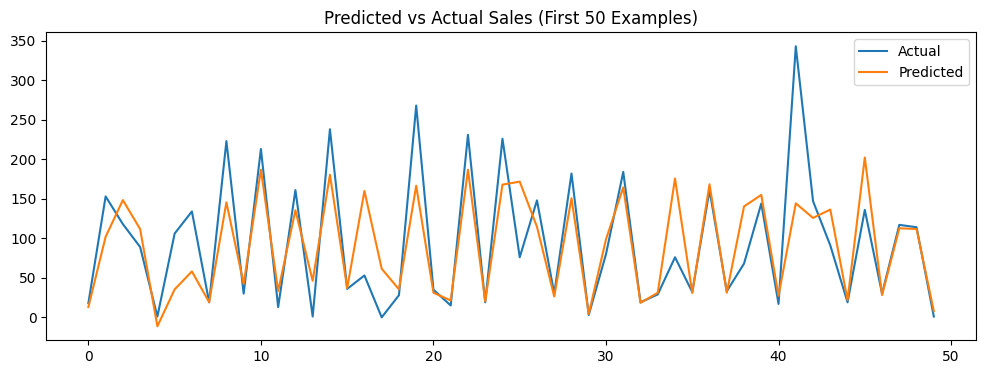

In [56]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred_lr[:50], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (First 50 Examples)')
plt.show()

#### Results

Random Forest evaluation:
MAE: 27.92331176246669
R²: 0.713426416408518

Linear Regression evaluation:
Linear Regression MAE: 30.227219973639944
Linear Regression R²: 0.6845980097683977

### 2. Ignore Single Dishes and Covid Years

In the original Excel files, the sales data (`Verkaufszahlen`) includes clear names for single dishes, which makes them easier for the model to predict. However, our main interest lies in forecasting sales for the "Essen" menus, whose names are often less descriptive. 

Additionally, visualizations show that sales patterns during the Covid-19 pandemic years (2020 and 2021) differ significantly from other years. To avoid bias and outliers in our analysis, we excluded both single dishes and data from the pandemic years. This allows us to focus on the more challenging and relevant task of predicting "Essen" sales under normal conditions.


In [57]:
# Exclude COVID years
df_no_covid = verkauf_df_enriched[~verkauf_df_enriched['year'].isin([2020, 2021])].copy()


In [58]:
# Essen 1–5 only
df_essen_only = verkauf_df_enriched[
    verkauf_df_enriched['original_name'].astype(str).str.contains(r"Essen\s[1-5]")
].copy()


In [59]:
df_essen_no_covid = df_essen_only[~df_essen_only['year'].isin([2020, 2021])].copy()


In [60]:
df_essen_no_covid.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,day,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,419,1
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1304,1
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1812,1
13,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,8,70.102019,63.182901,66.668705,62.374719,676,728.857143,789.846154,1523,1
14,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,8,70.102019,63.182901,66.668705,62.374719,676,702.428571,781.714286,666,1


In [61]:
base_features = [
    'year', 'weekday', 'month', 'day', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales'
]

X_n = df_essen_no_covid[base_features]
y_n = df_essen_no_covid['sold_amount']

In [62]:
split_index = int(len(X_n) * 0.8)
X_train_n, X_test_n = X_n.iloc[:split_index], X_n.iloc[split_index:]
y_train_n, y_test_n = y_n.iloc[:split_index], y_n.iloc[split_index:]

In [63]:
#Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_n, y_train_n)
y_pred_n = model.predict(X_test_n)

MAE_RF_essen = mean_absolute_error(y_test_n, y_pred_n)
R2_RF_essen = r2_score(y_test_n, y_pred_n)

print("Random Forest evaluation (df_essen_no_covid):")
print("MAE:", mean_absolute_error(y_test_n, y_pred_n))
print("R²:", r2_score(y_test_n, y_pred_n))

Random Forest evaluation (df_essen_no_covid):
MAE: 34.592273584905655
R²: 0.6164331456595515


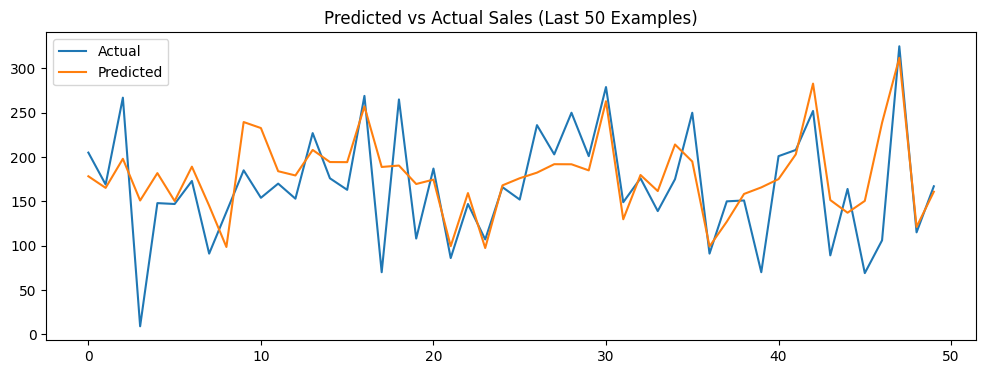

In [64]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_n.values[-50:], label='Actual')
plt.plot(y_pred_n[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

In [65]:
#Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_n, y_train_n)
y_pred_lr_n = lr.predict(X_test_n)

MAE_LR_essen = mean_absolute_error(y_test_n, y_pred_lr_n)
R2_LR_essen = r2_score(y_test_n, y_pred_lr_n)

print("Linear Regression (df_essen_no_covid) evaluation:")
print("Linear Regression MAE:", mean_absolute_error(y_test_n, y_pred_lr_n))
print("Linear Regression R²:", r2_score(y_test_n, y_pred_lr_n))


Linear Regression (df_essen_no_covid) evaluation:
Linear Regression MAE: 36.544382019654726
Linear Regression R²: 0.5971081754227476


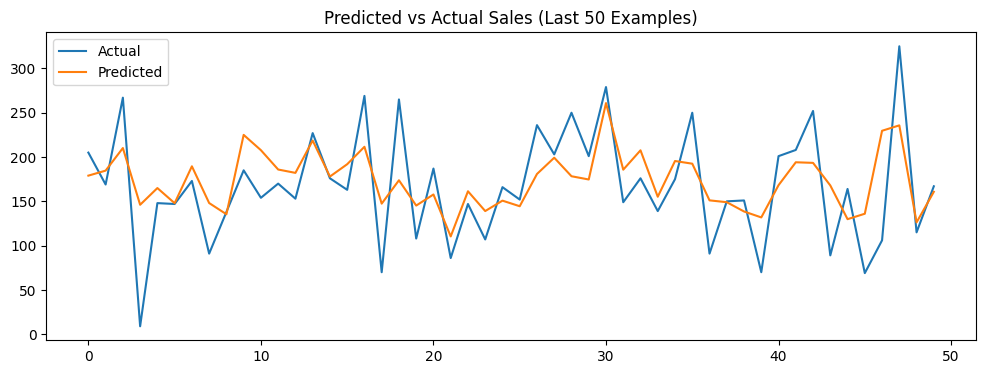

In [66]:
plt.figure(figsize=(12, 4))
plt.plot(y_test_n.values[-50:], label='Actual')
plt.plot(y_pred_lr_n[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

In [67]:
print(f"Random Forest evaluation (on full data):") 
print(f"MAE: {MAE_RF_full:.2f}")
print(f"R² Score: {R2_RF_full:.2f}\n")

print(f"Linear Regression evaluation (on full data):") 
print(f"MAE: {MAE_LR_full:.2f}")
print(f"R² Score: {R2_LR_full:.2f}\n")

print(f"Random Forest evaluation (Essen 1-5, no COVID):") 
print(f"MAE: {MAE_RF_essen:.2f}")
print(f"R² Score: {R2_RF_essen:.2f}\n")


print(f"Linear Regression evaluation (Essen 1-5, no COVID):") 
print(f"MAE: {MAE_LR_essen:.2f}")
print(f"R² Score: {R2_LR_essen:.2f}")

Random Forest evaluation (on full data):
MAE: 27.76
R² Score: 0.71

Linear Regression evaluation (on full data):
MAE: 30.23
R² Score: 0.68

Random Forest evaluation (Essen 1-5, no COVID):
MAE: 34.59
R² Score: 0.62

Linear Regression evaluation (Essen 1-5, no COVID):
MAE: 36.54
R² Score: 0.60


#### Results

Random Forest evaluation (Essen 1-5, no COVID):
MAE: 35.03
R² Score: 0.61

Linear Regression evaluation (Essen 1-5, no COVID):
MAE: 36.90
R² Score: 0.59

### 3. Prediction of total sales per day
In this section, we train a model to predict the total number of dishes sold per day.
This allows us to estimate overall demand for the Mensa on a daily level.
Such predictions can help with overall staff planning and kitchen logistics.

In [68]:
daily_df = verkauf_df_enriched.groupby('date').agg({
    'sold_amount': 'sum',
    'weekday': 'first',
    'month': 'first',
    'year': 'first',
    'weekofyear': 'first',
    'rolling_7d_total_sales': 'first' , 
    'rolling_30d_total_sales': 'first'
}).reset_index()

daily_df.rename(columns={'sold_amount': 'total_sales'}, inplace=True)


In [69]:
daily_df.head()

,date,total_sales,weekday,month,year,weekofyear,rolling_7d_total_sales,rolling_30d_total_sales
0,2014-01-07,861,1,1,2014,2,510.153182,510.445974
1,2014-01-08,676,2,1,2014,2,676.000000,774.666667
2,2014-01-09,868,3,1,2014,2,868.000000,801.666667
3,2014-01-10,563,4,1,2014,2,606.571429,754.166667
4,2014-01-13,815,0,1,2014,3,563.000000,724.366667


In [70]:
daily_df = daily_df.sort_values('date')

split_index = int(len(daily_df) * 0.8)
train_df = daily_df.iloc[:split_index]
test_df = daily_df.iloc[split_index:]


In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['weekday', 'month', 'weekofyear', 'rolling_7d_total_sales', 'rolling_30d_total_sales']
X_train = train_df[features]
y_train = train_df['total_sales']
X_test = test_df[features]
y_test = test_df['total_sales']

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



print("Random Forest (total sales per day):")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")


Random Forest (total sales per day):
MAE: 60.75
R²: 0.85


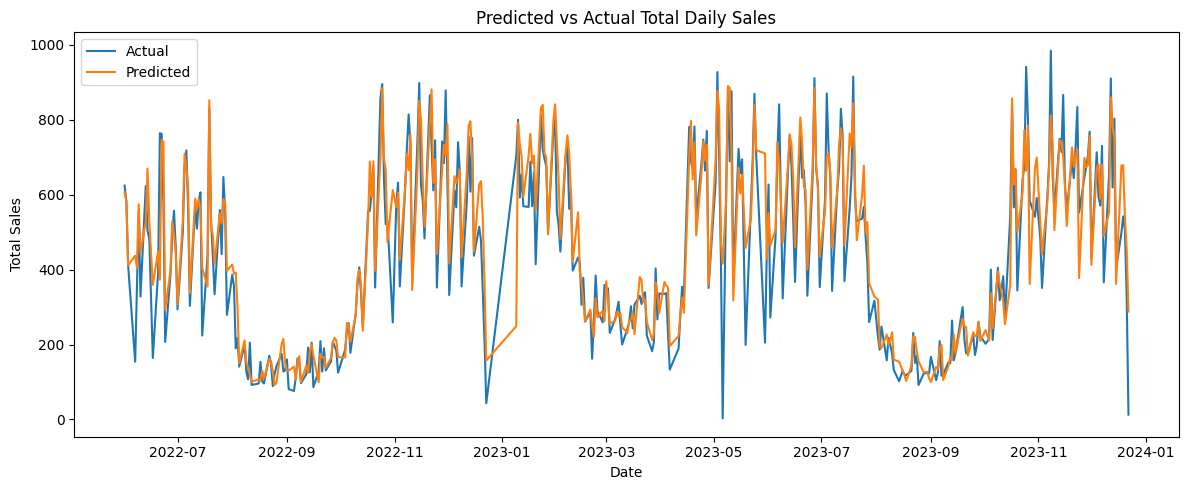

In [72]:
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], y_test, label='Actual')
plt.plot(test_df['date'], y_pred, label='Predicted')
plt.title('Predicted vs Actual Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

#### Results:

Random Forest (total sales per day):
MAE: 68.23
R²: 0.82

### 4. Prediction of Single Dish Sales

In this section, we aim to predict the sales of single dishes.  
Since we know all dish names in advance (there are only 25 unique single dishes), we could build a highly accurate model for this task.


In [73]:
df_single_dishes.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,day,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,510.153182,510.445974,945
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1506
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,625
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1417
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH),2,2014,Single dish,1,2,8,70.102019,63.182901,66.668705,62.374719,676,861.000000,861.000000,140


Label Encoding

In [74]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df_single_dishes['dish_encoded'] = encoder.fit_transform(df_single_dishes['original_name'])

In [75]:
df_single_dishes.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,day,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,dish_encoded
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,510.153182,510.445974,945,9
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1506,16
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,625,7
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1417,15
8,2014-01-08,Röstkartoffeln,34.0,34,Röstkartoffeln (EH),2,2014,Single dish,1,2,8,70.102019,63.182901,66.668705,62.374719,676,861.000000,861.000000,140,17


In [76]:
df_single_dishes = df_single_dishes.sort_values('date')

split_index = int(len(df_single_dishes) * 0.8)
train_df = df_single_dishes.iloc[:split_index]
test_df = df_single_dishes.iloc[split_index:]

In [77]:
features = [
    'dish_encoded', 'dish_freq', 'weekday', 'month', 'day', 'weekofyear',
    'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales'

]

X_train = train_df[features]
y_train = train_df['sold_amount']
X_test = test_df[features]
y_test = test_df['sold_amount']

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)



print("Random Forest (Single Dish Sales):")
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.2f}")

Random Forest (Single Dish Sales):
MAE: 20.82
R²: 0.26


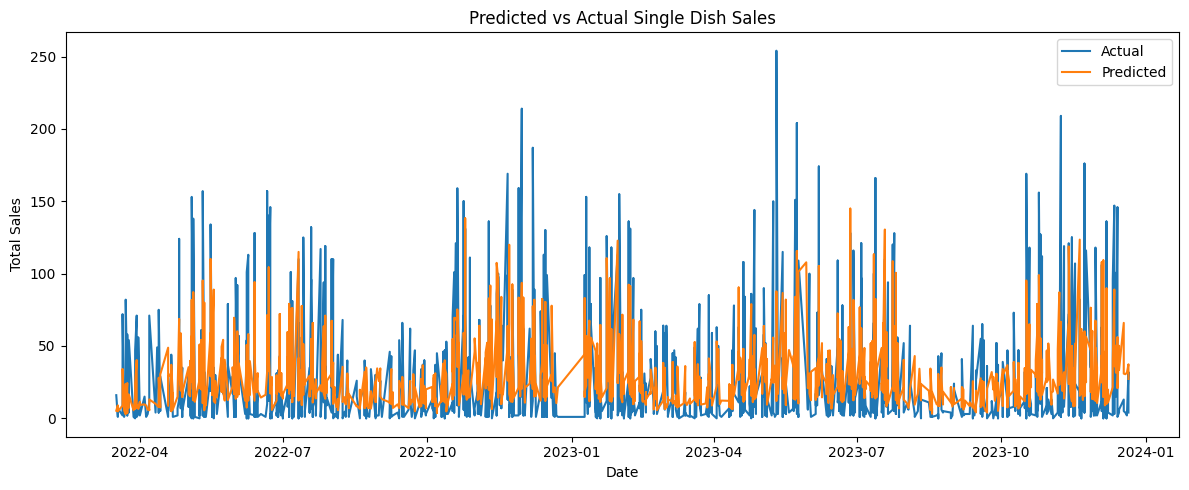

In [78]:
plt.figure(figsize=(12, 5))
plt.plot(test_df['date'], y_test, label='Actual')
plt.plot(test_df['date'], y_pred, label='Predicted')
plt.title('Predicted vs Actual Single Dish Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.show()

## Analysis after embedding

So far, our dataframes did not use any information about what the dish names mean. To make our predictions better, we will use LLMs (Large Language Models) to create embedding vectors for dish names. These embeddings help the model understand which dishes are similar. This should help us predict sales for each dish more accurately.

In [79]:
# Save df_essen_only as a pickle file for later use in embedding.
# Pickle format preserves all DataFrame information (data, types, index, etc.) for reliable reloading.

#df_essen_only.to_pickle('data/df_essen_only.pkl')

- In **embedding_generation.ipynb**, we created special "embeddings" (dish_embeddings.pkl) for each dish name using the Google Gemini API with the setting `task_type="SEMANTIC_SIMILARITY"`. This helps us find dishes that are similar, even if their names are a bit different.

By adding these advanced embeddings, our models can better understand and predict dish sales, even when dish names change or are written differently.

In [80]:
import pickle
import pandas as pd

with open('pickle_files/dish_embeddings.pkl', 'rb') as f:
    dish_embeddings = pickle.load(f)


embedding_df = pd.DataFrame.from_dict(dish_embeddings, orient='index')
embedding_df.reset_index(inplace=True)
embedding_df.rename(columns={'index': 'dish_name'}, inplace=True)


In [81]:
embedding_df.head()

,dish_name,0,1,2,3,4,5,6,7,8,...,758,759,760,761,762,763,764,765,766,767
0,Pasta mit Tomate-Gemüsesoße,0.021249,-0.034028,0.005527,0.009006,0.047246,0.023477,-0.002105,-0.016127,0.035557,...,-0.004310,0.020344,-0.051341,0.032908,-0.029573,0.000782,-0.043373,0.032240,-0.020990,-0.014158
1,Puten Cordon Bleu mit Zitrone,0.017317,-0.056851,-0.070699,-0.027099,0.014342,0.008165,-0.011565,-0.006481,0.034186,...,0.022824,0.018682,-0.067907,0.023231,-0.040663,0.060269,-0.005830,0.018221,-0.056192,-0.030810
2,Hacklett - Hacksteak,0.021459,-0.000691,-0.059774,-0.066763,0.038330,-0.001738,-0.013816,-0.016254,0.062202,...,0.019436,-0.001189,-0.023183,-0.011423,0.033921,0.018404,0.020297,-0.032669,-0.039641,0.008642
3,Nudelpfanne mit Muschelfleisch und Papri,-0.036713,-0.016585,0.000595,0.018914,0.016347,0.012880,-0.001823,-0.025439,0.029771,...,0.039184,0.022784,-0.046973,0.055940,-0.021821,-0.014707,-0.011800,0.017561,-0.032900,0.037525
4,Rösti Hauptgericht,-0.008220,-0.019783,-0.044453,-0.033724,0.014393,0.045740,-0.030042,-0.046713,0.018144,...,-0.017783,0.023003,-0.033578,0.006598,-0.025619,0.045689,-0.072074,-0.000586,-0.014357,0.013391


### PCA

The Google Gemini API gives us embedding vectors with 768 dimensions. This is too many features for most machine learning models. To solve this, we use PCA (Principal Component Analysis) to reduce the number of dimensions, while still keeping 90% of the important information (variance) in the data. This makes the data easier to work with and helps our models run faster and more accurately.

In [82]:
df_embeddings = pd.DataFrame([
    {'dish_name': name, 'embedding': emb}
    for name, emb in dish_embeddings.items()
])

In [83]:
df_embeddings.head()

,dish_name,embedding
0,Pasta mit Tomate-Gemüsesoße,"[0.02124859, -0.03402806, 0.0055268896, 0.0090..."
1,Puten Cordon Bleu mit Zitrone,"[0.01731671, -0.056851085, -0.07069918, -0.027..."
2,Hacklett - Hacksteak,"[0.021459313, -0.00069075805, -0.05977393, -0...."
3,Nudelpfanne mit Muschelfleisch und Papri,"[-0.03671253, -0.01658475, 0.0005951046, 0.018..."
4,Rösti Hauptgericht,"[-0.008220069, -0.019782962, -0.04445282, -0.0..."


In [84]:
from sklearn.decomposition import PCA
import numpy as np


X_embed = np.vstack(df_embeddings['embedding'].values)  # shape (n_samples, 768)

# Apply PCA to reduce dimensionality while preserving 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_embed)

print(f"Number of components explaining 95% variance: {pca.n_components_}")

pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_embed)

print(f"Number of components explaining 90% variance: {pca.n_components_}")

Number of components explaining 95% variance: 188
Number of components explaining 90% variance: 127


In [85]:
embeddings_127_components = embedding_df.copy()

pca = PCA(n_components=127, random_state=42)
X_embed = embeddings_127_components.drop(columns=['dish_name']).values
pca_result  = pca.fit_transform(X_embed)

pca_columns = [f'pca_{i+1}' for i in range(pca_result.shape[1])]
pca_df = pd.DataFrame(pca_result, columns=pca_columns)

pca_df['dish_name'] = embeddings_127_components['dish_name'].values
pca_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Columns: 128 entries, pca_1 to dish_name
dtypes: float64(127), object(1)
memory usage: 1.0+ MB


In [86]:
# Merge PCA results with the original df_essen_no_covid
essen_no_covid_with_pca = df_essen_no_covid.merge(pca_df, on='dish_name', how='left')

print(essen_no_covid_with_pca.shape)
essen_no_covid_with_pca.head()

(5300, 147)


,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,...,pca_118,pca_119,pca_120,pca_121,pca_122,pca_123,pca_124,pca_125,pca_126,pca_127
0,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,0.006497,-0.004815,0.000667,-0.009821,0.037431,-0.010406,0.017357,-0.016761,0.004587,0.003172
1,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,0.022939,-0.008693,-0.016705,0.012653,-0.011729,0.012472,-0.014748,-0.009212,0.001046,-0.008947
2,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,-0.005207,-0.021274,0.001834,0.003216,0.016199,-0.005852,-0.024457,-0.003974,0.011810,-0.023720
3,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,0.008354,0.008002,0.041180,0.013744,0.034645,-0.007646,-0.011517,-0.000148,-0.000862,-0.018620
4,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,0.011549,-0.012107,0.000317,0.025027,-0.025101,0.036164,-0.002136,0.012797,0.006999,-0.010691


### Random Forest Regressor (Base Features + PCA)

Since we have a large number of features after applying PCA, we will train a Random Forest Regressor to predict sales. This approach helps manage high-dimensional data efficiently and leverages the strengths of ensemble learning for improved prediction accuracy.

In [87]:
y = essen_no_covid_with_pca['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales'
]

pca_features = [col for col in essen_no_covid_with_pca.columns if col.startswith('pca_')]

X = essen_no_covid_with_pca[base_features + pca_features]

In [88]:
essen_no_covid_with_pca = essen_no_covid_with_pca.sort_values('date')
split_index = int(len(essen_no_covid_with_pca) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [89]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 33.517716981132075
R²: 0.6365590092423863


## Below we also trained many other models in order to improve our results.

### XGBoost (Base Features + PCA)

XGBoost is well-suited for cases with a large number of features, as it efficiently handles high-dimensional data and can automatically select the most important variables for prediction.

In [90]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

y = essen_no_covid_with_pca['sold_amount']

X = essen_no_covid_with_pca[base_features + pca_features]

essen_no_covid_with_pca = essen_no_covid_with_pca.sort_values('date')
split_idx = int(len(essen_no_covid_with_pca) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]


In [91]:
model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)


In [92]:
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")

XGBoost MAE: 32.04
XGBoost R²: 0.66


#### Grid Search for XGBoost 
- max_depth
- learning_rate
- n_estimators

**Goal:**  
Grid Search is used to systematically explore combinations of key hyperparameters for XGBoost (such as `max_depth`, `learning_rate`, and `n_estimators`) to find the optimal settings that maximize model performance. By evaluating different parameter values, we aim to improve prediction accuracy and generalization, ensuring the model is neither underfitting nor overfitting the data.

In [93]:

from sklearn.model_selection import GridSearchCV

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300]
}

# Grid Search
grid_search = GridSearchCV(estimator=xgb_model,
                           param_grid=param_grid,
                           cv=3,
                           scoring='neg_mean_absolute_error',
                           verbose=2,
                           n_jobs=-1)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best MAE (neg): {grid_search.best_score_:.2f}")


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}
Best MAE (neg): -33.15


In [94]:
y_pred_best = grid_search.best_estimator_.predict(X_test)

In [95]:

mae = mean_absolute_error(y_test, y_pred_best)
r2 = r2_score(y_test, y_pred_best)

print(f"XGBoost with best parameters")
print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")


XGBoost with best parameters
XGBoost MAE: 32.41
XGBoost R²: 0.66


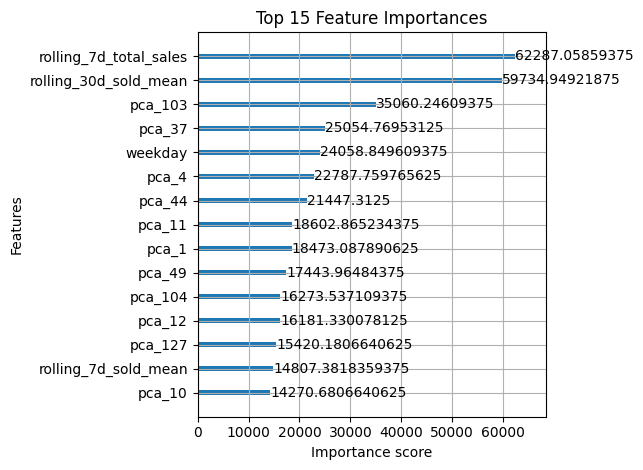

In [96]:
#Importance of features

xgb.plot_importance(grid_search.best_estimator_, max_num_features=15, importance_type='gain')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()


After performing grid search for hyperparameter tuning, the model's performance slightly decreased compared to the default parameters

### Text-based Clustering (without LLM) 

Optional


In [97]:
''''
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


unique_dishes = essen_no_covid_with_pca['dish_name'].dropna().unique()

vectorizer = TfidfVectorizer()
X_tfidf = vectorizer.fit_transform(unique_dishes)

n_clusters=150

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(X_tfidf)

dish_to_cluster = dict(zip(unique_dishes, clusters))

essen_nc_pca_cluster = essen_no_covid_with_pca.copy()
essen_nc_pca_cluster['dish_cluster'] = essen_nc_pca_cluster['dish_name'].map(dish_to_cluster)
'''

"'\nfrom sklearn.feature_extraction.text import TfidfVectorizer\nfrom sklearn.cluster import KMeans\n\n\nunique_dishes = essen_no_covid_with_pca['dish_name'].dropna().unique()\n\nvectorizer = TfidfVectorizer()\nX_tfidf = vectorizer.fit_transform(unique_dishes)\n\nn_clusters=150\n\nkmeans = KMeans(n_clusters=n_clusters, random_state=42)\nclusters = kmeans.fit_predict(X_tfidf)\n\ndish_to_cluster = dict(zip(unique_dishes, clusters))\n\nessen_nc_pca_cluster = essen_no_covid_with_pca.copy()\nessen_nc_pca_cluster['dish_cluster'] = essen_nc_pca_cluster['dish_name'].map(dish_to_cluster)\n"

In [98]:
'''
for cluster_id in range(10, 15):
    cluster_members = essen_nc_pca_cluster[essen_nc_pca_cluster['dish_cluster'] == cluster_id]['dish_name'].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")
    for name in cluster_members:
        print(f"  - {name}")
    print()
'''

'\nfor cluster_id in range(10, 15):\n    cluster_members = essen_nc_pca_cluster[essen_nc_pca_cluster[\'dish_cluster\'] == cluster_id][\'dish_name\'].tolist()\n    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")\n    for name in cluster_members:\n        print(f"  - {name}")\n    print()\n'

In [99]:
'''
y = essen_nc_pca_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'dish_cluster'
]

X = essen_nc_pca_cluster[base_features + pca_features]

essen_nc_pca_cluster = essen_nc_pca_cluster.sort_values('date')
split_index = int(len(essen_nc_pca_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
'''

'\ny = essen_nc_pca_cluster[\'sold_amount\']\n\n# Features\nbase_features = [\n    \'year\', \'weekday\', \'month\', \'day\', \'weekofyear\',\n     \'rolling_7d_sold_mean\', \'rolling_7d_sold_median\',    \n    \'rolling_30d_sold_mean\', \'rolling_30d_sold_median\',\n    \'rolling_7d_total_sales\', \'rolling_30d_total_sales\', \'dish_cluster\'\n]\n\nX = essen_nc_pca_cluster[base_features + pca_features]\n\nessen_nc_pca_cluster = essen_nc_pca_cluster.sort_values(\'date\')\nsplit_index = int(len(essen_nc_pca_cluster) * 0.8)\n\nX_train, X_test = X.iloc[:split_index], X.iloc[split_index:]\ny_train, y_test = y.iloc[:split_index], y.iloc[split_index:]\n\nmodel = RandomForestRegressor(n_estimators=100, random_state=42)\nmodel.fit(X_train, y_train)\ny_pred = model.predict(X_test)\n\nMAE_RF = mean_absolute_error(y_test, y_pred)\nR2_RF = r2_score(y_test, y_pred)\n\nprint("Random Forest evaluation:")\nprint("MAE:", mean_absolute_error(y_test, y_pred))\nprint("R²:", r2_score(y_test, y_pred))\n'

### Embedding with clustering

- In **embedding_clustering.ipynb**, we made another set of embeddings (dish_embeddings_clustering.pkl) using `task_type="CLUSTERING"`. These are designed to group dishes into clusters based on how similar they are.

In [100]:
with open('pickle_files/dish_embeddings_clustering.pkl', 'rb') as f:
    dish_embeddings_clustering = pickle.load(f)

In [101]:

embedding_clustering_df = pd.DataFrame.from_dict(dish_embeddings_clustering, orient='index')
embedding_clustering_df.reset_index(inplace=True)
embedding_clustering_df.rename(columns={'index': 'dish_name'}, inplace=True)

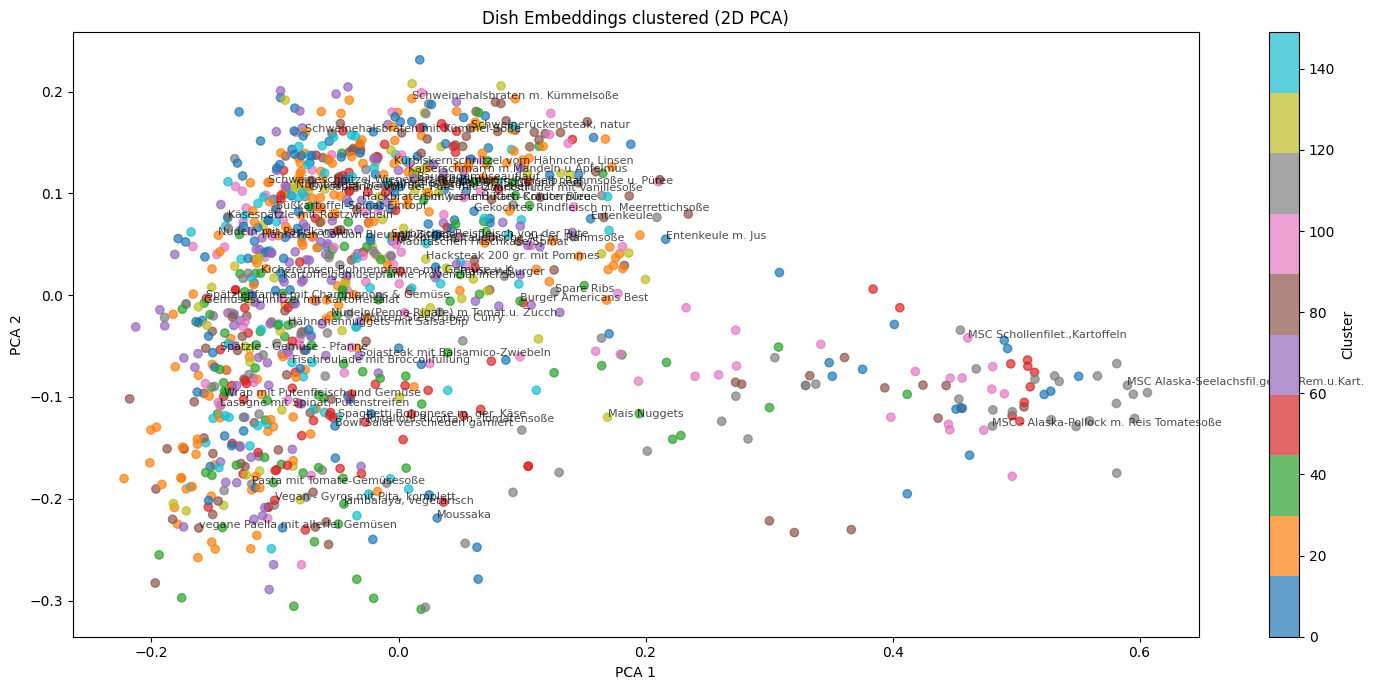

In [102]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# Assume embedding_clustering_df has 'dish_name' and embedding columns (e.g., 0, 1, ..., n)
embedding_cols = [col for col in embedding_clustering_df.columns if col != 'dish_name']
X = embedding_clustering_df[embedding_cols].values

# Cluster the embeddings
n_clusters = 150
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
embedding_clustering_df['cluster'] = kmeans.fit_predict(X)

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(15, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=embedding_clustering_df['cluster'], cmap='tab10', alpha=0.7)
plt.title('Dish Embeddings clustered (2D PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
for i, name in enumerate(embedding_clustering_df['dish_name']):
    if i % 20 == 0:  # annotate every 20th for readability
        plt.annotate(name, (X_pca[i, 0], X_pca[i, 1]), fontsize=8, alpha=0.7)
plt.tight_layout()
plt.show()



Example of Clusters:

In [103]:
for cluster_id in range(17, 20):
    cluster_members = embedding_clustering_df[embedding_clustering_df['cluster'] == cluster_id]['dish_name'].tolist()
    print(f"Cluster {cluster_id} ({len(cluster_members)} dishes):")
    for name in cluster_members:
        print(f"  - {name}")
    print()

Cluster 17 (25 dishes):
  - Pasta mit Räuchertofu und Champignons
  - Gemüse - Bolognese mit Spaghetti
  - Pasta Aglio e olio mit Gemüse
  - Pasta mit Gemüse in Käse-Kräutersoße
  - Pasta Asciutta mit Reibekäse
  - Pasta mit Broccoli und Paprika
  - Pasta mit Garnelen
  - Pasta mit Schinken
  - Pasta mit Lachs und Broccoli in Sahnesoß
  - Pasta mit Meeresfrüchten
  - Pasta Funghi m. Vollkornnudeln
  - Pasta mit Tofu und Champignons
  - Ravioli (Hackfl.) mit Gemüsesoße
  - Pasta mit Gemüse und Pesto
  - Spaghettimit Kapern,Peperoni, Oliven und
  -  Spaghetti mit  Pilzen und Schinken
  - Pasta  mit buntem Gemüse
  - Pasta mit Gemüse in Kräutersoße
  - Pasta mit Gemüsebolognese
  - Pasta mit Soja und Gemüse
  - Pasta mit Auberginen und Tomaten
  - Spaghetti mit Ratatouille und Hüttenkäse
  - Pasta mit Gemüse
  - Pasta mit Broccoliröschen und Walnüssen
  - Gemüselasagne m. Kräutersoße

Cluster 18 (6 dishes):
  - Hacklett - Hacksteak
  - Texashacksteak
  - Hacklett -Hacksteak
  - Rinderhack

#### Methods to find optimal number of clusters

To find the number of unique dish names and improve our model results, we tried two common methods for choosing the best number of clusters. However, these methods did not give clear answers for our data. So, we picked a number of clusters that seemed reasonable based on our own judgment.

- **Elbow Method**

In [104]:
"""
inertia = []
cluster_range = range(2, 250) 

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X) 
    inertia.append(kmeans.inertia_)

plt.plot(cluster_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()
"""

"\ninertia = []\ncluster_range = range(2, 250) \n\nfor k in cluster_range:\n    kmeans = KMeans(n_clusters=k, random_state=42)\n    kmeans.fit(X) \n    inertia.append(kmeans.inertia_)\n\nplt.plot(cluster_range, inertia, marker='o')\nplt.xlabel('Number of Clusters (k)')\nplt.ylabel('Inertia')\nplt.title('Elbow Method for Optimal k')\nplt.show()\n"

- **Silhouette Score**


In [105]:
"""
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(300, 500):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)

plt.plot(range(300, 500), silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

"""

"\nfrom sklearn.metrics import silhouette_score\n\nsilhouette_scores = []\nfor k in range(300, 500):\n    kmeans = KMeans(n_clusters=k, random_state=42)\n    cluster_labels = kmeans.fit_predict(X)\n    score = silhouette_score(X, cluster_labels)\n    silhouette_scores.append(score)\n\nplt.plot(range(300, 500), silhouette_scores, marker='o')\nplt.xlabel('Number of Clusters (k)')\nplt.ylabel('Silhouette Score')\nplt.title('Silhouette Analysis')\nplt.show()\n\n"

#### Random Forest Regressor (Base Features + Cluster))

In [106]:
embedding_clustering_df['cluster'].head()

0    119
1     63
2     18
3     72
4    126
Name: cluster, dtype: int32

In [107]:
df_essen_no_covid_cluster = df_essen_no_covid.copy()
df_essen_no_covid_cluster['cluster'] = df_essen_no_covid_cluster['dish_name'].map(embedding_clustering_df.set_index('dish_name')['cluster'])

In [108]:
df_essen_no_covid_cluster.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,...,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen,cluster
5,2014-01-07,Essen 3,190.0,185,Pasta mit Tomate-Gemüsesoße,1,2014,Essen (Menu),1,2,...,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,419,1,119
6,2014-01-07,Essen 2,240.0,237,Puten Cordon Bleu mit Zitrone,1,2014,Essen (Menu),1,2,...,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1304,1,63
7,2014-01-07,Essen 1,162.0,159,Hacklett - Hacksteak,1,2014,Essen (Menu),1,2,...,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1812,1,18
13,2014-01-08,Essen 4,60.0,52,Nudelpfanne mit Muschelfleisch und Papri,2,2014,Essen (Menu),1,2,...,70.102019,63.182901,66.668705,62.374719,676,728.857143,789.846154,1523,1,72
14,2014-01-08,Essen 5,270.0,265,Rösti Hauptgericht,2,2014,Essen (Menu),1,2,...,70.102019,63.182901,66.668705,62.374719,676,702.428571,781.714286,666,1,126


In [109]:
y = df_essen_no_covid_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'cluster'
]

X = df_essen_no_covid_cluster[base_features]

df_essen_no_covid_cluster = df_essen_no_covid_cluster.sort_values('date')
split_index = int(len(df_essen_no_covid_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 34.3672641509434
R²: 0.61592437083349


#### Random Forest Regressor (Base Feature + PCA + Cluster)

In [110]:
essen_no_covid_pca_cluster = essen_no_covid_with_pca.copy()
essen_no_covid_pca_cluster['cluster'] = essen_no_covid_with_pca['dish_name'].map(embedding_clustering_df.set_index('dish_name')['cluster'])

In [111]:
y = essen_no_covid_pca_cluster['sold_amount']

# Features
base_features = [
    'year', 'weekday', 'month', 'day', 'weekofyear',
     'rolling_7d_sold_mean', 'rolling_7d_sold_median',    
    'rolling_30d_sold_mean', 'rolling_30d_sold_median',
    'rolling_7d_total_sales', 'rolling_30d_total_sales', 'cluster'
]

X = essen_no_covid_pca_cluster[base_features + pca_features]

essen_no_covid_pca_cluster = essen_no_covid_pca_cluster.sort_values('date')
split_index = int(len(essen_no_covid_pca_cluster) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

MAE_RF = mean_absolute_error(y_test, y_pred)
R2_RF = r2_score(y_test, y_pred)

print("Random Forest evaluation:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

Random Forest evaluation:
MAE: 33.397358490566035
R²: 0.6356301293607132


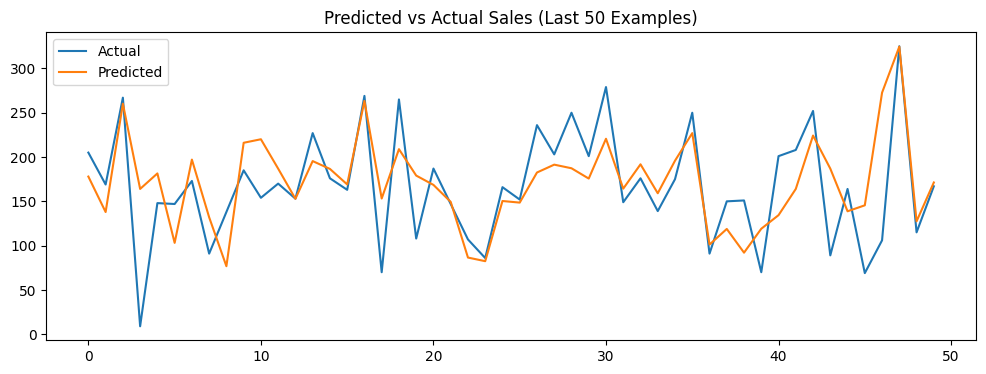

In [112]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values[-50:], label='Actual')
plt.plot(y_pred[-50:], label='Predicted')
plt.legend()
plt.title('Predicted vs Actual Sales (Last 50 Examples)')
plt.show()

#### XGBoost (Base Features + PCA + Cluster)

In [113]:


model_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

In [114]:
mae = mean_absolute_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost R²: {r2:.2f}")


XGBoost MAE: 32.69
XGBoost R²: 0.66


### Results

In [115]:
verkauf_df_enriched['target_amount'] = verkauf_df_enriched['target_amount'].fillna(0)

In [116]:
verkauf_df_enriched.head()

,date,original_name,target_amount,sold_amount,dish_name,weekday,year,dish_type,month,weekofyear,day,rolling_7d_sold_mean,rolling_7d_sold_median,rolling_30d_sold_mean,rolling_30d_sold_median,daily_total_sales,rolling_7d_total_sales,rolling_30d_total_sales,dish_freq,is_essen
0,2014-01-07,Kartoffelsalat,80.0,74,Kartoffelsalat fertig,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,510.153182,510.445974,945,0
1,2014-01-07,Reis,15.0,15,Butterreis,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1506,0
2,2014-01-07,Kartoffeln,3.0,3,"Kartoffeln, geschält",1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,625,0
3,2014-01-07,Essen- Soziales ohne Berechnung,0.0,1,Essen- Soziales ohne Berechnung,1,2014,Essen (Menu),1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,192,1
4,2014-01-07,Pommes frites,200.0,187,Pommes-Frites,1,2014,Single dish,1,2,7,70.102019,63.182901,66.668705,62.374719,861,861.000000,861.000000,1417,0


In [117]:
mae_baseline = mean_absolute_error(
    verkauf_df_enriched[verkauf_df_enriched['is_essen'] == 1]['sold_amount'],
    verkauf_df_enriched[verkauf_df_enriched['is_essen'] == 1]['target_amount']
)
print(f"Baseline MAE (Mensa plan, Essen only): {mae_baseline:.2f}")

Baseline MAE (Mensa plan, Essen only): 14.66


#### Conclusion

Even with advanced machine learning models and extra features (like embeddings and clustering), the best model in this project got an MAE of 32.04 and an R² of 0.66 for predicting dish sales in the KU Mensa (using XGBoost with base features and PCA).

In comparison, the Mensa staff's own forecasts are much better, with an MAE of only 14.66. This means that while the model can predict general sales trends, it is still not as accurate as the staff, who have a lot of experience and knowledge.